# **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import zipfile
import os
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense , Dropout , Activation , Flatten
from keras.layers import Conv2D , MaxPooling2D , GlobalMaxPooling2D , BatchNormalization
from warnings import filterwarnings
filterwarnings('ignore')

## **Import Dataset**

In [ ]:
zip_path = "/content/Dataset.zip"
extract_path = "/content/Dataset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = extract_path

## **Show Dataset**

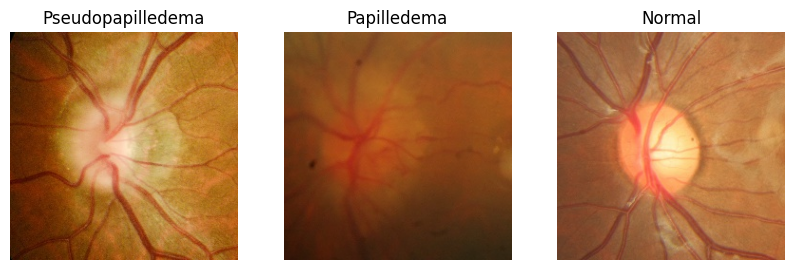

In [ ]:
class_names = os.listdir(dataset_path)
class_names = [cls for cls in class_names if os.path.isdir(os.path.join(dataset_path, cls))]

plt.figure(figsize=(10, 10))
for i, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)
    plt.subplot(1, len(class_names), i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [ ]:
image_size = (224, 224)
data = []
labels = []

for label, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        image = Image.open(image_path).resize(image_size)
        data.append(np.array(image))
        labels.append(label)

data = np.array(data)
labels = np.array(labels)

print("Initial data shape")
print(f"Data shape: {data.shape}, labels shape: {labels.shape}")

Initial data shape
Data shape: (1369, 224, 224, 3), labels shape: (1369,)


## **Normalization**

In [ ]:
data = data / 255.0

# **Transformers Feature Extraction**

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Flatten

In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Flatten()(x)

In [ ]:
model = Model(inputs=base_model.input, outputs=x)

In [ ]:
features = model.predict(data)

43/43 ━━━━━━━━━━━━━━━━━━━━ 266s 6s/step


In [ ]:
features.shape

(1369, 2048)

In [ ]:
features = features.reshape(features.shape[0], -1)
df = pd.DataFrame(features)
df

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,0.0,0.0,0.000000,0.0,1.137612,0.0,0.0,0.968594,0.000108,0.0,...,0.0,0.0,0.0,0.0,0.020343,0.0,0.0,1.738186,0.0,0.0
1,0.0,0.0,0.000000,0.0,1.137802,0.0,0.0,0.974090,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.016782,0.0,0.0,1.717696,0.0,0.0
2,0.0,0.0,0.000000,0.0,1.128406,0.0,0.0,0.960944,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.017422,0.0,0.0,1.683177,0.0,0.0
3,0.0,0.0,0.000137,0.0,1.132895,0.0,0.0,0.977376,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.015485,0.0,0.0,1.705654,0.0,0.0
4,0.0,0.0,0.000000,0.0,1.149532,0.0,0.0,0.974955,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.016631,0.0,0.0,1.682082,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1364,0.0,0.0,0.000000,0.0,1.128168,0.0,0.0,0.979509,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.015961,0.0,0.0,1.667103,0.0,0.0
1365,0.0,0.0,0.000000,0.0,1.144380,0.0,0.0,0.963247,0.000562,0.0,...,0.0,0.0,0.0,0.0,0.017635,0.0,0.0,1.683352,0.0,0.0
1366,0.0,0.0,0.000000,0.0,1.163825,0.0,0.0,0.964259,0.002557,0.0,...,0.0,0.0,0.0,0.0,0.018380,0.0,0.0,1.726206,0.0,0.0
1367,0.0,0.0,0.003495,0.0,1.147276,0.0,0.0,0.983620,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.015919,0.0,0.0,1.710524,0.0,0.0


In [ ]:
df.sum()[df.sum()>0]

,0
2,0.244715
4,1554.944702
7,1327.899658
8,0.388592
12,203.885880
...,...
2031,1358.452393
2034,5.877030
2036,4.435350
2042,23.626015


In [ ]:
df = df.loc[:, (df != 0).any(axis=0)]
df

,2,4,7,8,12,13,14,19,22,24,...,2006,2008,2012,2025,2027,2031,2034,2036,2042,2045
0,0.000000,1.137612,0.968594,0.000108,0.150288,0.0,0.777189,0.001944,0.527172,0.412829,...,0.001738,0.868900,0.015283,0.0,0.000584,0.994894,0.004784,0.003790,0.020343,1.738186
1,0.000000,1.137802,0.974090,0.000000,0.154040,0.0,0.734810,0.001684,0.523424,0.392476,...,0.000962,0.876868,0.011958,0.0,0.000000,0.985962,0.006596,0.003564,0.016782,1.717696
2,0.000000,1.128406,0.960944,0.000000,0.150284,0.0,0.744860,0.002060,0.515007,0.368141,...,0.000087,0.859318,0.012880,0.0,0.000139,0.983279,0.004788,0.002626,0.017422,1.683177
3,0.000137,1.132895,0.977376,0.000000,0.144870,0.0,0.742366,0.001857,0.525474,0.382219,...,0.000007,0.863086,0.010490,0.0,0.000588,0.991124,0.005525,0.003559,0.015485,1.705654
4,0.000000,1.149532,0.974955,0.000000,0.148538,0.0,0.757294,0.001856,0.524453,0.384937,...,0.000000,0.861259,0.013253,0.0,0.000624,0.990562,0.003973,0.003090,0.016631,1.682082
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1364,0.000000,1.128168,0.979509,0.000000,0.144621,0.0,0.745882,0.001479,0.526638,0.377881,...,0.000372,0.872447,0.013710,0.0,0.000556,1.004592,0.005176,0.003322,0.015961,1.667103
1365,0.000000,1.144380,0.963247,0.000562,0.153820,0.0,0.734036,0.001967,0.513356,0.388108,...,0.000855,0.882081,0.013213,0.0,0.000349,0.980994,0.002966,0.003125,0.017635,1.683352
1366,0.000000,1.163825,0.964259,0.002557,0.161678,0.0,0.765113,0.001758,0.514072,0.419816,...,0.000024,0.883232,0.016340,0.0,0.000130,0.989112,0.004511,0.002839,0.018380,1.726206
1367,0.003495,1.147276,0.983620,0.000000,0.153398,0.0,0.759385,0.001409,0.538668,0.391107,...,0.000800,0.878592,0.010938,0.0,0.000460,1.010766,0.005779,0.003872,0.015919,1.710524


In [ ]:
df['label'] = labels

df

,2,4,7,8,12,13,14,19,22,24,...,2008,2012,2025,2027,2031,2034,2036,2042,2045,label
0,0.000000,1.137612,0.968594,0.000108,0.150288,0.0,0.777189,0.001944,0.527172,0.412829,...,0.868900,0.015283,0.0,0.000584,0.994894,0.004784,0.003790,0.020343,1.738186,0
1,0.000000,1.137802,0.974090,0.000000,0.154040,0.0,0.734810,0.001684,0.523424,0.392476,...,0.876868,0.011958,0.0,0.000000,0.985962,0.006596,0.003564,0.016782,1.717696,0
2,0.000000,1.128406,0.960944,0.000000,0.150284,0.0,0.744860,0.002060,0.515007,0.368141,...,0.859318,0.012880,0.0,0.000139,0.983279,0.004788,0.002626,0.017422,1.683177,0
3,0.000137,1.132895,0.977376,0.000000,0.144870,0.0,0.742366,0.001857,0.525474,0.382219,...,0.863086,0.010490,0.0,0.000588,0.991124,0.005525,0.003559,0.015485,1.705654,0
4,0.000000,1.149532,0.974955,0.000000,0.148538,0.0,0.757294,0.001856,0.524453,0.384937,...,0.861259,0.013253,0.0,0.000624,0.990562,0.003973,0.003090,0.016631,1.682082,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1364,0.000000,1.128168,0.979509,0.000000,0.144621,0.0,0.745882,0.001479,0.526638,0.377881,...,0.872447,0.013710,0.0,0.000556,1.004592,0.005176,0.003322,0.015961,1.667103,2
1365,0.000000,1.144380,0.963247,0.000562,0.153820,0.0,0.734036,0.001967,0.513356,0.388108,...,0.882081,0.013213,0.0,0.000349,0.980994,0.002966,0.003125,0.017635,1.683352,2
1366,0.000000,1.163825,0.964259,0.002557,0.161678,0.0,0.765113,0.001758,0.514072,0.419816,...,0.883232,0.016340,0.0,0.000130,0.989112,0.004511,0.002839,0.018380,1.726206,2
1367,0.003495,1.147276,0.983620,0.000000,0.153398,0.0,0.759385,0.001409,0.538668,0.391107,...,0.878592,0.010938,0.0,0.000460,1.010766,0.005779,0.003872,0.015919,1.710524,2


# **Data Preprocessing**

## **Feature Selection**

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2

In [ ]:
X = df.drop('label', axis=1)
y = df['label']

selector = SelectKBest(chi2, k=10)
X_new = selector.fit_transform(X, y)

selected_indices = selector.get_support(indices=True)
scores = selector.scores_

selected_features_df = pd.DataFrame({'Feature': X.columns, 'Score': scores}).sort_values(by='Score', ascending=False)
selected_features_df = selected_features_df.iloc[selected_indices]

selected_features_df

,Feature,Score
550,1730,0.518514
438,1383,0.068480
151,450,0.030017
489,1555,0.023276
306,943,0.021278
568,1807,0.008229
110,344,0.004785
72,240,0.004619
177,530,0.003961
168,491,0.000228


In [ ]:
df = df[selected_features_df['Feature'].tolist() + ['label']]
df

,1730,1383,450,1555,943,1807,344,240,530,491,label
0,1.001256,0.063801,0.102167,0.445159,0.144991,0.049018,0.622049,0.004091,0.133330,0.0,0
1,1.029898,0.065857,0.101288,0.461239,0.143162,0.050718,0.628615,0.003477,0.136886,0.0,0
2,0.998085,0.064009,0.097762,0.450943,0.136560,0.051460,0.623732,0.004257,0.139544,0.0,0
3,1.010236,0.060972,0.097749,0.441255,0.141469,0.050256,0.620299,0.003441,0.135957,0.0,0
4,1.015091,0.061601,0.099637,0.448370,0.140554,0.051179,0.621311,0.003265,0.141888,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...
1364,0.968773,0.061940,0.098650,0.430473,0.141450,0.052422,0.615275,0.003489,0.135545,0.0,2
1365,1.011827,0.063658,0.097663,0.436030,0.140514,0.053274,0.613351,0.004255,0.139823,0.0,2
1366,1.038671,0.066206,0.100210,0.444097,0.127078,0.055022,0.613091,0.003096,0.141539,0.0,2
1367,0.981445,0.064873,0.101740,0.446836,0.145308,0.051667,0.620713,0.004203,0.143784,0.0,2


## **Handle Outliers**

<Axes: >

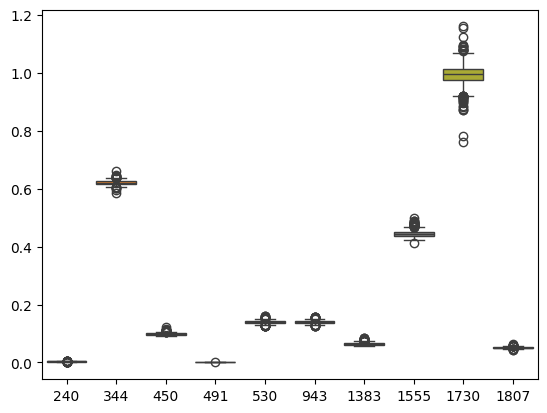

In [ ]:
sns.boxplot(data=df.drop('label', axis=1))

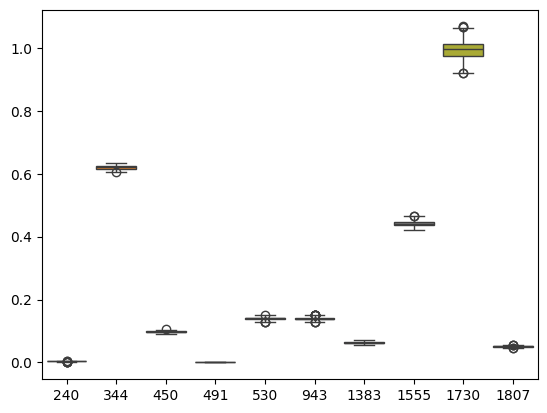

In [ ]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_no_outliers = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_no_outliers


for column in df.drop('label', axis=1).columns:
  df = remove_outliers_iqr(df, column)

sns.boxplot(data=df.drop('label', axis=1))
plt.show()

In [ ]:
df

,1730,1383,450,1555,943,1807,344,240,530,491,label
0,1.001256,0.063801,0.102167,0.445159,0.144991,0.049018,0.622049,0.004091,0.133330,0.0,0
1,1.029898,0.065857,0.101288,0.461239,0.143162,0.050718,0.628615,0.003477,0.136886,0.0,0
2,0.998085,0.064009,0.097762,0.450943,0.136560,0.051460,0.623732,0.004257,0.139544,0.0,0
3,1.010236,0.060972,0.097749,0.441255,0.141469,0.050256,0.620299,0.003441,0.135957,0.0,0
4,1.015091,0.061601,0.099637,0.448370,0.140554,0.051179,0.621311,0.003265,0.141888,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...
1363,0.985428,0.064108,0.100804,0.438213,0.140769,0.051906,0.624119,0.003479,0.146285,0.0,2
1364,0.968773,0.061940,0.098650,0.430473,0.141450,0.052422,0.615275,0.003489,0.135545,0.0,2
1365,1.011827,0.063658,0.097663,0.436030,0.140514,0.053274,0.613351,0.004255,0.139823,0.0,2
1367,0.981445,0.064873,0.101740,0.446836,0.145308,0.051667,0.620713,0.004203,0.143784,0.0,2


## **Handle Imbalanced Data**

In [ ]:
df['label'].value_counts()

,count
label,
2,614
0,287
1,266


In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
X = df.drop('label', axis=1)
y = df['label']


smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['label'] = y_resampled

df = df_resampled

df['label'].value_counts()

,count
label,
0,614
1,614
2,614


In [ ]:
df

,1730,1383,450,1555,943,1807,344,240,530,491,label
0,1.001256,0.063801,0.102167,0.445159,0.144991,0.049018,0.622049,0.004091,0.133330,0.0,0
1,1.029898,0.065857,0.101288,0.461239,0.143162,0.050718,0.628615,0.003477,0.136886,0.0,0
2,0.998085,0.064009,0.097762,0.450943,0.136560,0.051460,0.623732,0.004257,0.139544,0.0,0
3,1.010236,0.060972,0.097749,0.441255,0.141469,0.050256,0.620299,0.003441,0.135957,0.0,0
4,1.015091,0.061601,0.099637,0.448370,0.140554,0.051179,0.621311,0.003265,0.141888,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...
1837,0.963273,0.060275,0.094503,0.440039,0.135344,0.051204,0.616890,0.003541,0.139255,0.0,1
1838,0.965727,0.059357,0.094053,0.443766,0.138036,0.053001,0.616175,0.003908,0.138393,0.0,1
1839,0.948882,0.061547,0.095997,0.435899,0.138844,0.052255,0.613476,0.003569,0.142538,0.0,1
1840,0.966968,0.058733,0.095745,0.437268,0.136896,0.050567,0.618878,0.003583,0.142526,0.0,1


## **Checking Dupplicate**

In [ ]:
df.duplicated().sum()

0

## **Train-Test Split**

In [ ]:
X = df.iloc[:,:-1]
Y = df.iloc[:,-1]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.3, random_state = 0)

In [ ]:
df_train = pd.concat([X_train, Y_train], axis = 1).reset_index().drop("index", axis = 1)
df_test = pd.concat([X_test, Y_test], axis = 1).reset_index().drop("index", axis = 1)

In [ ]:
df_train

,1730,1383,450,1555,943,1807,344,240,530,491,label
0,0.979561,0.062334,0.097777,0.448363,0.142781,0.054076,0.621118,0.003530,0.140933,0.0,2
1,0.990473,0.060737,0.095523,0.441746,0.138211,0.051107,0.618016,0.003797,0.139108,0.0,0
2,1.017160,0.062854,0.099311,0.456680,0.141508,0.050417,0.620647,0.003167,0.139941,0.0,2
3,0.962908,0.064760,0.096553,0.449441,0.142962,0.051063,0.614492,0.003546,0.142242,0.0,1
4,0.978763,0.060222,0.094778,0.441923,0.136328,0.051277,0.620634,0.003392,0.139424,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...
1284,1.022293,0.066237,0.102497,0.441811,0.147252,0.047849,0.631206,0.003429,0.148375,0.0,2
1285,0.996281,0.064419,0.097792,0.437839,0.139437,0.051367,0.621723,0.003458,0.138513,0.0,0
1286,1.007657,0.058583,0.096000,0.449778,0.135387,0.049716,0.622584,0.003261,0.139882,0.0,1
1287,0.995693,0.061974,0.100403,0.452185,0.144559,0.051127,0.623653,0.003558,0.139960,0.0,2


In [ ]:
df_test

,1730,1383,450,1555,943,1807,344,240,530,491,label
0,0.984930,0.058794,0.094950,0.442349,0.137856,0.052337,0.618026,0.003425,0.138623,0.0,1
1,1.010553,0.062474,0.097997,0.444569,0.141868,0.052622,0.624828,0.003754,0.133297,0.0,0
2,0.990057,0.060315,0.095578,0.444795,0.136171,0.052874,0.618019,0.003832,0.141032,0.0,1
3,0.998593,0.063618,0.099969,0.452324,0.150770,0.049699,0.623325,0.003343,0.132374,0.0,2
4,0.944772,0.062078,0.098167,0.431405,0.139575,0.050715,0.620625,0.003223,0.146084,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...
548,0.975197,0.064066,0.095773,0.435211,0.128987,0.055162,0.624580,0.004065,0.137171,0.0,1
549,1.000949,0.057955,0.094494,0.441485,0.135079,0.049682,0.617953,0.003466,0.139337,0.0,0
550,1.005108,0.066454,0.095098,0.435532,0.140795,0.054853,0.613944,0.003358,0.134267,0.0,2
551,0.969238,0.071663,0.104756,0.453833,0.147712,0.049529,0.612568,0.003140,0.144742,0.0,2


## **Feature Scaling**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
X_tr = df_train.iloc[:,:-1]
Y_tr = df_train.iloc[:,-1]

In [ ]:
mm = MinMaxScaler()
X_mm_tr = mm.fit_transform(X_tr)

In [ ]:
df_X_tr = pd.DataFrame(X_mm_tr, columns = X_tr.columns)
df_train = pd.concat([df_X_tr, Y_tr], axis = 1)
df_train

,1730,1383,450,1555,943,1807,344,240,530,491,label
0,0.401611,0.428894,0.423363,0.602772,0.616200,0.825667,0.568810,0.496059,0.547057,0.0,2
1,0.476536,0.330906,0.251749,0.456198,0.408572,0.508056,0.457684,0.619136,0.455740,0.0,0
2,0.659790,0.460758,0.540211,0.786970,0.558341,0.434251,0.551960,0.329075,0.497422,0.0,2
3,0.287255,0.577707,0.330174,0.626632,0.624432,0.503297,0.331421,0.503579,0.612576,0.0,1
4,0.396130,0.299333,0.195088,0.460128,0.323043,0.526278,0.551468,0.432551,0.471539,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...
1284,0.695038,0.668271,0.782772,0.457648,0.819308,0.159530,0.930254,0.449877,0.919491,0.0,2
1285,0.516423,0.556757,0.424549,0.369682,0.464263,0.535826,0.590517,0.462898,0.425965,0.0,0
1286,0.594537,0.198792,0.288132,0.634097,0.280330,0.359236,0.621347,0.372480,0.494478,0.0,1
1287,0.512386,0.406772,0.623290,0.687424,0.696934,0.510215,0.659645,0.509118,0.498360,0.0,2


In [ ]:
X_te = df_test.iloc[:,:-1]
Y_te = df_test.iloc[:,-1]

In [ ]:
X_test_mm = mm.transform(X_te)

In [ ]:
df_x_test_mm = pd.DataFrame(X_test_mm, columns = X_te.columns)
df_test = pd.concat([df_x_test_mm, Y_te], axis = 1)
df_test

,1730,1383,450,1555,943,1807,344,240,530,491,label
0,0.438475,0.211708,0.208124,0.469565,0.392449,0.639598,0.458052,0.448004,0.431462,0.0,1
1,0.614422,0.437446,0.440165,0.518726,0.574712,0.670067,0.701733,0.599167,0.164954,0.0,0
2,0.473682,0.305006,0.255948,0.523748,0.315935,0.697025,0.457794,0.635075,0.552047,0.0,1
3,0.532300,0.507651,0.590277,0.690505,0.979116,0.357450,0.647892,0.410098,0.118758,0.0,2
4,0.162721,0.413154,0.453104,0.227160,0.470550,0.466160,0.551157,0.354869,0.804857,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...
548,0.371641,0.535128,0.270794,0.311477,-0.010395,0.941797,0.692854,0.742533,0.358789,0.0,1
549,0.548474,0.160254,0.173454,0.450434,0.266325,0.355569,0.455433,0.466662,0.467216,0.0,0
550,0.577033,0.681583,0.219423,0.318565,0.525986,0.908731,0.311806,0.417189,0.213493,0.0,2
551,0.330721,1.001143,0.954702,0.723911,0.840162,0.339212,0.262505,0.316389,0.737670,0.0,2


# **Learning Algorithms**

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV

In [ ]:
X_train = df_train.iloc[:,:-1]
Y_train = df_train.iloc[:,-1]
X_test = df_test.iloc[:,:-1]
Y_test = df_test.iloc[:,-1]

## **KNN**

In [ ]:
# Training Model
from sklearn.neighbors import KNeighborsClassifier

KNN_model = KNeighborsClassifier(n_neighbors = 6, metric = "minkowski", p = 7)
KNN_model.fit(X_train, Y_train)

KNeighborsClassifier(n_neighbors=6, p=7)

In [ ]:
# Predict Validation and test data
y_knn_pred = KNN_model.predict(X_test)
y_knn_pred

array([1, 0, 1, 2, 1, 1, 0, 1, 1, 1, 2, 2, 0, 0, 1, 2, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 2, 0, 2, 0, 1, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 2,
       0, 2, 0, 0, 1, 2, 0, 2, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 2, 1, 2, 1,
       1, 0, 2, 1, 2, 1, 2, 0, 1, 2, 0, 0, 0, 2, 2, 0, 2, 2, 1, 1, 2, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 2, 0, 0, 2, 1, 1, 2, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 2, 0, 0, 2, 0, 0, 2, 1, 1, 2, 2, 1, 0, 0, 2,
       2, 2, 1, 0, 0, 0, 1, 2, 0, 2, 0, 1, 0, 1, 2, 1, 1, 1, 0, 2, 0, 0,
       0, 1, 0, 2, 0, 1, 0, 2, 1, 2, 1, 1, 0, 1, 1, 0, 2, 2, 0, 2, 0, 0,
       2, 0, 0, 2, 0, 1, 1, 0, 0, 1, 0, 0, 2, 2, 1, 1, 2, 0, 0, 1, 0, 2,
       2, 1, 2, 0, 0, 2, 0, 2, 2, 2, 2, 1, 2, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 2, 2, 1, 1, 2, 0, 0, 1, 0, 0, 1, 0, 1, 2, 0, 2, 0, 0, 0, 0, 2,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 2, 1, 0, 0, 1,
       0, 0, 2, 1, 2, 1, 1, 2, 0, 2, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 2,
       0, 1, 2, 0, 0, 1, 1, 0, 2, 2, 0, 0, 0, 1, 0,

In [ ]:
# Evaluation
confusion_matrix(y_knn_pred, Y_test)

array([[171,  20,  54],
       [  9, 156,  15],
       [ 14,   4, 110]])

In [ ]:
accuracy_score(y_knn_pred, Y_test)

0.7902350813743219

In [ ]:
precision_score(y_knn_pred, Y_test , average='macro')

0.7875450351001811

In [ ]:
recall_score(y_knn_pred, Y_test, average='macro')

0.808000283446712

In [ ]:
knn_predicted_prob = KNN_model.predict_proba(X_test)
knn_predicted_prob

array([[0.        , 1.        , 0.        ],
       [0.5       , 0.        , 0.5       ],
       [0.        , 1.        , 0.        ],
       ...,
       [0.16666667, 0.        , 0.83333333],
       [0.        , 0.        , 1.        ],
       [0.        , 0.        , 1.        ]])

## **SVM**

In [ ]:
from sklearn.svm import SVC

In [ ]:
#Grid Search hyperparameters for Support Vector Classifier
from sklearn.model_selection import RepeatedKFold

#Define Model
model = SVC()

#Define Evaluation method
cv = RepeatedKFold(n_splits = 10, n_repeats = 3)

#Define Grid
grid = dict()
grid["kernel"] = ["linear", "rbf"]
grid["C"] = range(1,11)
grid["gamma"] = ["auto", "scale"]

#Define Search
search = GridSearchCV(model, grid, scoring = "accuracy", cv = cv, n_jobs = -1)

#Perform Search
results = search.fit(X_train, Y_train)

#Finalization
print(results.best_params_)


{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [ ]:
# Training Model
SVC_model = SVC(kernel = 'rbf',
                C = 10,
                gamma = 'scale',
                probability=True)
SVC_model.fit(X_train, Y_train)

SVC(C=10, probability=True)

In [ ]:
# Predict Validation and test data
y_svc_pred = SVC_model.predict(X_test)

In [ ]:
# Evaluation
confusion_matrix(y_svc_pred, Y_test)

array([[157,  11,  28],
       [ 15, 163,   9],
       [ 22,   6, 142]])

In [ ]:
accuracy_score(y_svc_pred, Y_test)

0.8354430379746836

In [ ]:
precision_score(y_svc_pred, Y_test, average='macro')

0.8360433318188315

In [ ]:
recall_score(y_svc_pred, Y_test, average='macro')

0.8359907599403398

In [ ]:
f1_score(y_svc_pred, Y_test, average='macro')

0.8357217218455634

In [ ]:
SVC_predicted_prob = SVC_model.predict_proba(X_test)
SVC_predicted_prob

array([[1.83222349e-02, 9.62359179e-01, 1.93185861e-02],
       [3.40072650e-01, 3.91563926e-03, 6.56011710e-01],
       [3.79532358e-02, 8.77711243e-01, 8.43355213e-02],
       ...,
       [2.00826490e-02, 6.36407058e-03, 9.73553280e-01],
       [3.14191106e-03, 8.84900738e-02, 9.08368015e-01],
       [5.18110510e-03, 4.23590032e-05, 9.94776536e-01]])

## **Decision Tree**

In [ ]:
#import important libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [ ]:
#Hyperparameters Tuning
max_depth = []
acc_gini = []
acc_entropy = []

for i in range(1,21):
  dtree = DecisionTreeClassifier(criterion = "gini", max_depth = i)
  dtree.fit(X_train, Y_train)
  dtree_pred = dtree.predict(X_test)
  acc_gini.append(accuracy_score(Y_test, dtree_pred))

  dtree = DecisionTreeClassifier(criterion = "entropy", max_depth = i)
  dtree.fit(X_train, Y_train)
  dtree_pred = dtree.predict(X_test)
  acc_entropy.append(accuracy_score(Y_test, dtree_pred))

  max_depth.append(i)

In [ ]:
#Making a DataFrame for categorize variables
df = pd.DataFrame({"acc_gini" : pd.Series(acc_gini),
                   "acc_entropy" : pd.Series(acc_entropy),
                   "max_depth" : pd.Series(max_depth)})

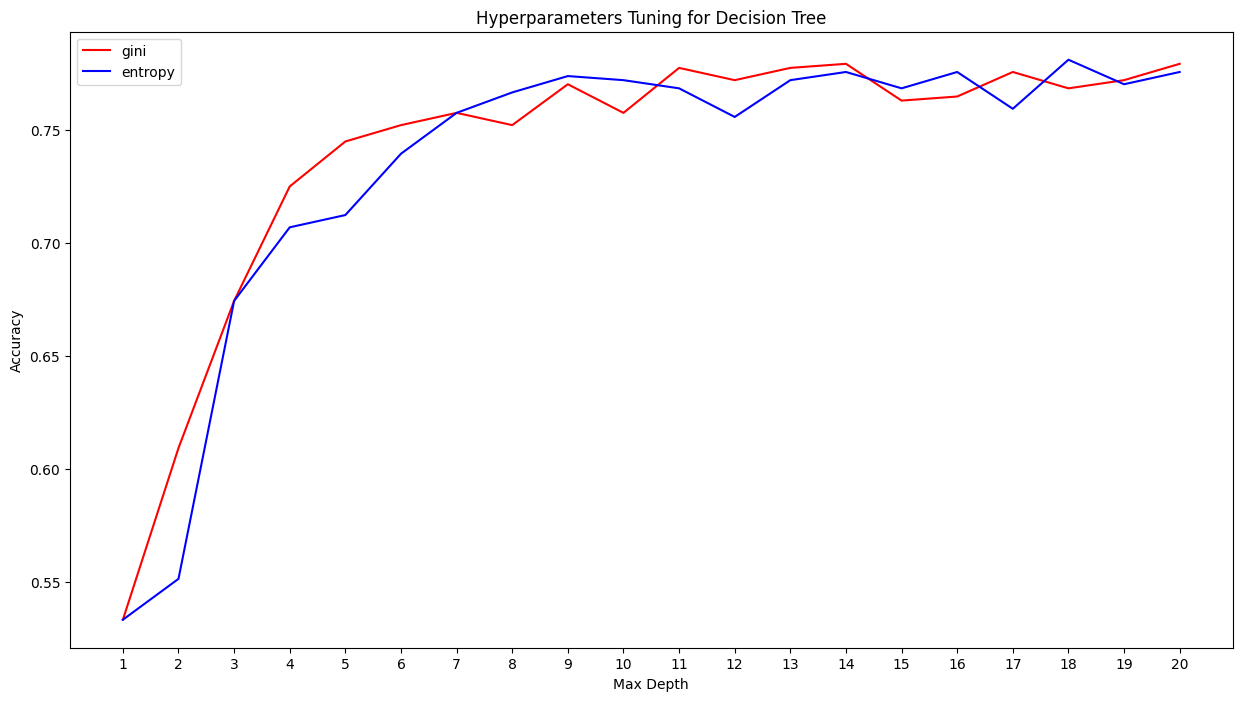

In [ ]:
#Visualising Data Frame
fig = plt.figure(figsize = (15,8))
plt.plot("max_depth", "acc_gini", data = df, label = "gini", color = "red")
plt.plot("max_depth", "acc_entropy", data = df, label = "entropy", color = "blue")

plt.title("Hyperparameters Tuning for Decision Tree")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.xticks([j for j in range(1,21)])
plt.legend()
plt.show()

In [ ]:
if acc_gini[-1] <= acc_entropy[-1]:
  Criterion = "gini"
else :
  Criterion = "entropy"
for i in range(1 , 21):
  if acc_gini[-i] == acc_entropy[-i]:
    Max_depth = 21-i
    break

In [ ]:
DT_model = DecisionTreeClassifier(criterion = Criterion, max_depth = Max_depth)
DT_model.fit(X_train, Y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=7)

In [ ]:
X_train.columns

Index([1730, 1383, 450, 1555, 943, 1807, 344, 240, 530, 491], dtype='object')

In [ ]:
import six
import sys
sys.modules["sklearn.externals.six"] = six

In [ ]:
from sklearn.externals.six import StringIO            #show leafs
import pydotplus                                      #illustrate texts on leafs and trees
from sklearn.tree import export_graphviz              #show trees
from IPython.display import Image

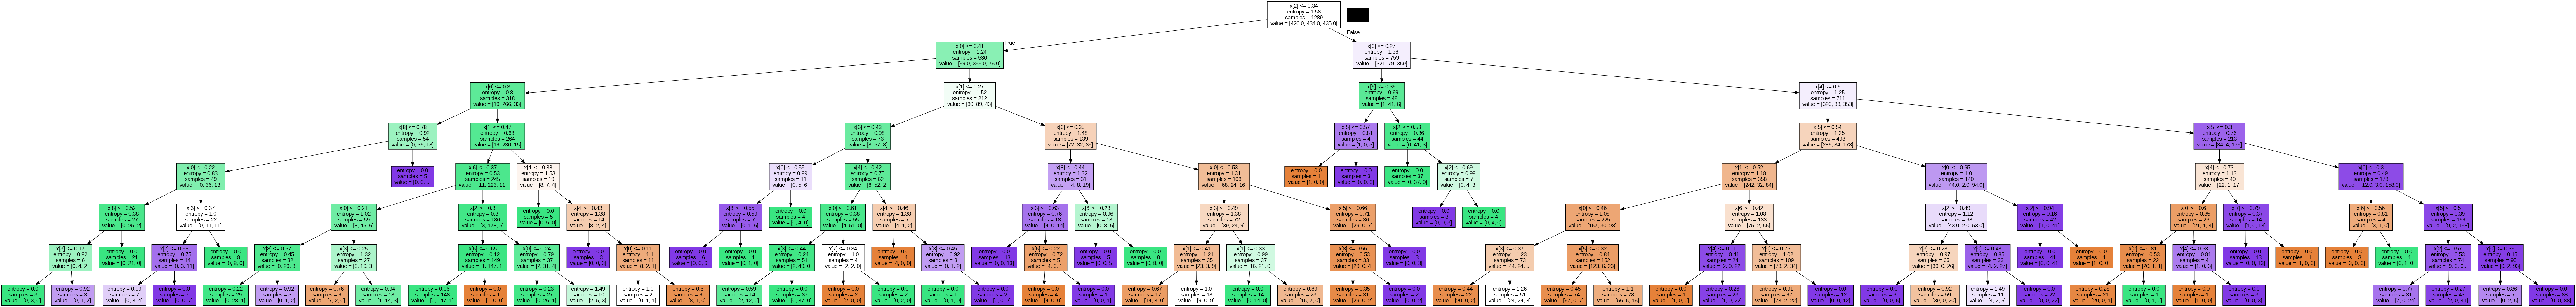

In [ ]:
dot_data = StringIO()
export_graphviz(DT_model, out_file = dot_data, filled = True, precision = 2)
# precision = 2 : for binary target
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

In [ ]:
# Predict Validation and test data
y_dt_pred = DT_model.predict(X_test)
y_dt_pred

array([1, 0, 1, 2, 1, 0, 0, 1, 1, 1, 2, 0, 0, 0, 0, 2, 1, 1, 0, 0, 0, 2,
       2, 0, 2, 2, 2, 2, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 0, 0, 2, 1, 2,
       2, 2, 2, 0, 1, 1, 0, 2, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 2, 0, 2, 1,
       1, 2, 2, 0, 2, 1, 2, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 1, 1, 2, 0,
       1, 0, 1, 0, 0, 1, 2, 0, 2, 0, 0, 2, 1, 1, 2, 0, 2, 1, 0, 1, 0, 1,
       0, 0, 0, 2, 2, 0, 1, 2, 0, 1, 0, 2, 1, 2, 1, 0, 2, 2, 1, 1, 0, 2,
       0, 2, 2, 0, 2, 0, 0, 2, 2, 2, 0, 1, 0, 1, 2, 1, 1, 0, 0, 2, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 2, 1, 1, 0, 1, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 0, 0, 2, 0, 0, 1, 0, 0, 1, 0, 0, 2, 2, 0, 1, 2, 1, 0, 1, 2, 0,
       0, 1, 0, 1, 0, 2, 2, 2, 2, 2, 0, 1, 2, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       2, 2, 0, 1, 2, 2, 0, 0, 1, 0, 2, 1, 0, 1, 2, 0, 2, 0, 1, 0, 0, 2,
       2, 0, 0, 0, 0, 1, 0, 0, 0, 1, 2, 0, 1, 1, 0, 2, 0, 0, 1, 2, 0, 1,
       0, 2, 2, 1, 2, 1, 1, 2, 2, 0, 1, 0, 0, 1, 2, 1, 1, 0, 0, 2, 1, 0,
       0, 1, 2, 0, 0, 1, 1, 0, 0, 2, 0, 0, 0, 1, 0,

In [ ]:
# Evaluation
confusion_matrix(y_dt_pred, Y_test)

array([[159,  31,  47],
       [ 12, 140,  10],
       [ 23,   9, 122]])

In [ ]:
accuracy_score(y_dt_pred, Y_test)

0.7613019891500904

In [ ]:
precision_score(y_dt_pred, Y_test, average='macro')

0.7596432174846043

In [ ]:
recall_score(y_dt_pred, Y_test, average='macro')

0.7757637996737855

In [ ]:
f1_score(y_dt_pred, Y_test, average='macro')

0.7630884028490574

In [ ]:
DT_predicted_prob = DT_model.predict_proba(X_test)
DT_predicted_prob

array([[0.        , 1.        , 0.        ],
       [0.66101695, 0.        , 0.33898305],
       [0.        , 1.        , 0.        ],
       ...,
       [0.        , 0.        , 1.        ],
       [0.04651163, 0.        , 0.95348837],
       [0.04651163, 0.        , 0.95348837]])

## **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Grid Search hyperparameters for RandomForest Classifier
from sklearn.model_selection import RepeatedKFold

#Define Model
model = RandomForestClassifier()

#Define Evaluation method
cv = RepeatedKFold(n_splits = 10, n_repeats = 3)

#Define Grid
grid = dict()
grid["n_estimators"] = range(50,150,20)
grid["criterion"] = ["gini", "entropy"]
grid["max_depth"] = range(1,15 , 3)

#Define Search
search = GridSearchCV(model, grid, scoring = "accuracy", cv = cv, n_jobs = -1)

#Perform Search
results = search.fit(X_train, Y_train)

#Finalization
print(results.best_params_)

{'criterion': 'entropy', 'max_depth': 13, 'n_estimators': 130}


In [ ]:
RF_model = RandomForestClassifier(n_estimators = 130 ,
                                  criterion = 'entropy',
                                  max_depth = 13)
RF_model.fit(X_train, Y_train)

RandomForestClassifier(criterion='entropy', max_depth=13, n_estimators=130)

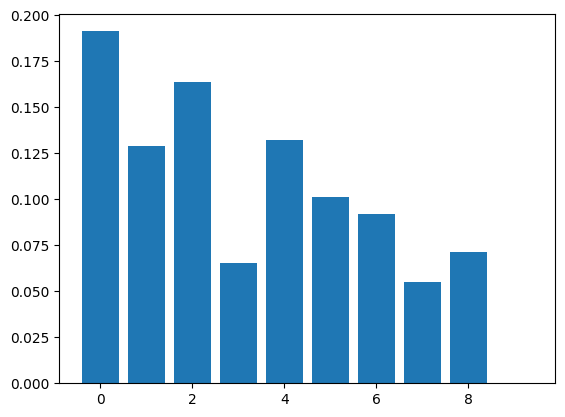

In [ ]:
importance = RF_model.feature_importances_

plt.bar([i for i in range(len(importance))], importance)
plt.show()

In [ ]:
# Predict Validation and test data
y_rf_pred = RF_model.predict(X_test)

In [ ]:
# Evaluation
confusion_matrix(y_rf_pred, Y_test)

array([[161,  11,  24],
       [  8, 165,   8],
       [ 25,   4, 147]])

In [ ]:
accuracy_score(y_rf_pred, Y_test)

0.8553345388788427

In [ ]:
precision_score(y_rf_pred, Y_test, average='macro')

0.8559308747208304

In [ ]:
recall_score(y_rf_pred, Y_test, average='macro')

0.8560860180335318

In [ ]:
f1_score(y_rf_pred, Y_test, average='macro')

0.8559791545160825

In [ ]:
RF_predicted_prob = RF_model.predict_proba(X_test)
RF_predicted_prob

array([[0.04615385, 0.86153846, 0.09230769],
       [0.32333841, 0.00601737, 0.67064422],
       [0.10104895, 0.88356643, 0.01538462],
       ...,
       [0.14615385, 0.10769231, 0.74615385],
       [0.13076923, 0.26923077, 0.6       ],
       [0.07628205, 0.        , 0.92371795]])

## **Extreme Gradient Boosting (XGBoost)**

In [ ]:
from xgboost.sklearn import XGBClassifier

In [ ]:
#Grid Search hyperparameters for XGB Classifier
from sklearn.model_selection import RepeatedKFold

#Define Model
model = XGBClassifier()

#Define Evaluation method
cv = RepeatedKFold(n_splits = 10, n_repeats = 3)

#Define Grid
grid = dict()
grid["learning_rate"] = [0.1, 0.2, 0.3, 0.4, 0.5]
grid["min_child_weight"] = [0.5 , 0.6 , 0.7 , 0.8, 0.9, 1]
grid["max_depth"] = range(1,15,3)

#Define Search
search = GridSearchCV(model, grid, scoring = "neg_mean_absolute_error", cv = cv, n_jobs = -1)

#Perform Search
results = search.fit(X_train, Y_train)

#Finalization
print(results.best_params_)

{'learning_rate': 0.3, 'max_depth': 7, 'min_child_weight': 1}


In [ ]:
XGB_model = XGBClassifier(learning_rate = 0.3 ,
                          max_depth = 7 ,
                          min_child_weight = 1 )
XGB_model.fit(X_train, Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

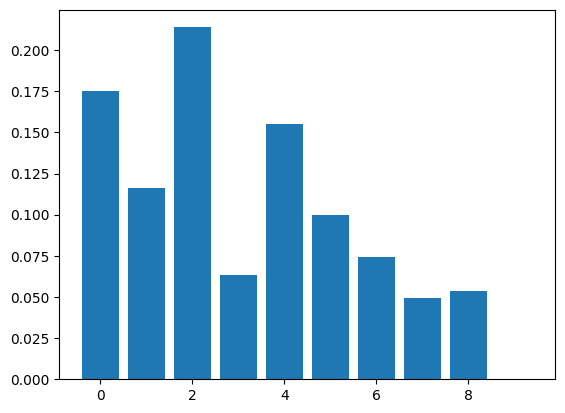

In [ ]:
importance = XGB_model.feature_importances_

plt.bar([i for i in range(len(importance))], importance)
plt.show()

In [ ]:
# Predict Validation and test data
y_xgb_pred = XGB_model.predict(X_test)

In [ ]:
# Evaluation
confusion_matrix(y_xgb_pred, Y_test)

array([[153,   5,  29],
       [ 11, 169,   7],
       [ 30,   6, 143]])

In [ ]:
accuracy_score(y_xgb_pred, Y_test)

0.840867992766727

In [ ]:
precision_score(y_xgb_pred, Y_test, average='macro')

0.8421437880891892

In [ ]:
recall_score(y_xgb_pred, Y_test, average='macro')

0.8402692717513617

In [ ]:
f1_score(y_xgb_pred, Y_test, average='macro')

0.8410044047646587

In [ ]:
XGB_predicted_prob = XGB_model.predict_proba(X_test)
XGB_predicted_prob

array([[2.4870518e-04, 9.9480236e-01, 4.9489550e-03],
       [4.9740918e-02, 6.5214065e-04, 9.4960690e-01],
       [4.2600330e-04, 9.9914789e-01, 4.2607705e-04],
       ...,
       [3.1341854e-03, 1.0648955e-03, 9.9580091e-01],
       [1.4091348e-03, 9.7303120e-03, 9.8886055e-01],
       [1.2151948e-03, 2.6037036e-05, 9.9875879e-01]], dtype=float32)

## **Naive Bias**

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
NB_model = GaussianNB()
NB_model.fit(X_train, Y_train)

GaussianNB()

In [ ]:
y_nb_pred = NB_model.predict(X_test)

In [ ]:
# Evaluation
confusion_matrix(y_nb_pred, Y_test)

array([[133,  23,  33],
       [ 28, 147,  17],
       [ 33,  10, 129]])

In [ ]:
accuracy_score(y_nb_pred, Y_test)

0.7396021699819169

In [ ]:
precision_score(y_nb_pred, Y_test, average='macro')

0.7409680226791325

In [ ]:
recall_score(y_nb_pred, Y_test, average='macro')

0.7397762345679012

In [ ]:
f1_score(y_nb_pred, Y_test, average='macro')

0.7399607623224232

In [ ]:
NB_predicted_prob = NB_model.predict_proba(X_test)
NB_predicted_prob

array([[1.78384037e-02, 9.76135703e-01, 6.02589366e-03],
       [4.64676941e-01, 2.52830863e-04, 5.35070228e-01],
       [4.71259892e-02, 9.35733459e-01, 1.71405516e-02],
       ...,
       [1.42388929e-02, 3.87410962e-04, 9.85373696e-01],
       [9.40129516e-08, 1.83224295e-14, 9.99999906e-01],
       [1.30785719e-02, 7.36209097e-09, 9.86921421e-01]])

## **ROC**

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

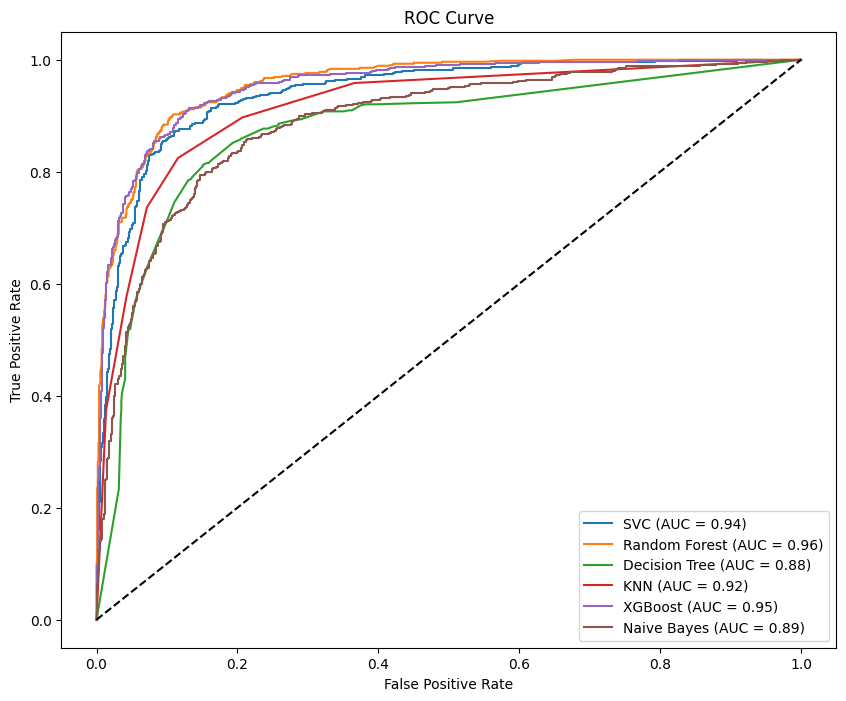

In [ ]:
# Binarize the output
y_test_bin = label_binarize(Y_test, classes=np.unique(Y_test))
n_classes = y_test_bin.shape[1]

def plot_roc_curve(models, model_names, X_test, y_test_bin):
    plt.figure(figsize=(10, 8))
    for i, model in enumerate(models):
      if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
      elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
      else:
        print(f"Warning: {model_names[i]} does not have predict_proba or decision_function. Skipping ROC curve.")
        continue

      fpr = dict()
      tpr = dict()
      roc_auc = dict()
      for j in range(n_classes):
          fpr[j], tpr[j], _ = roc_curve(y_test_bin[:, j], y_score[:, j])
          roc_auc[j] = auc(fpr[j], tpr[j])
      fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
      roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
      plt.plot(fpr["micro"], tpr["micro"], label=f'{model_names[i]} (AUC = {roc_auc["micro"]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

# Define the models and their names
models = [SVC_model, RF_model, DT_model, KNN_model, XGB_model, NB_model]
model_names = ['SVC', 'Random Forest', 'Decision Tree', 'KNN', 'XGBoost', 'Naive Bayes']

# Plot the ROC curve
plot_roc_curve(models, model_names, X_test, y_test_bin)